Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 2594 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): country, city, original_currency
dbl (4): hourly_wage_gbp, price_gbp, price, hourly_wage
lgl (3): urban, suburban, rural

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet thi

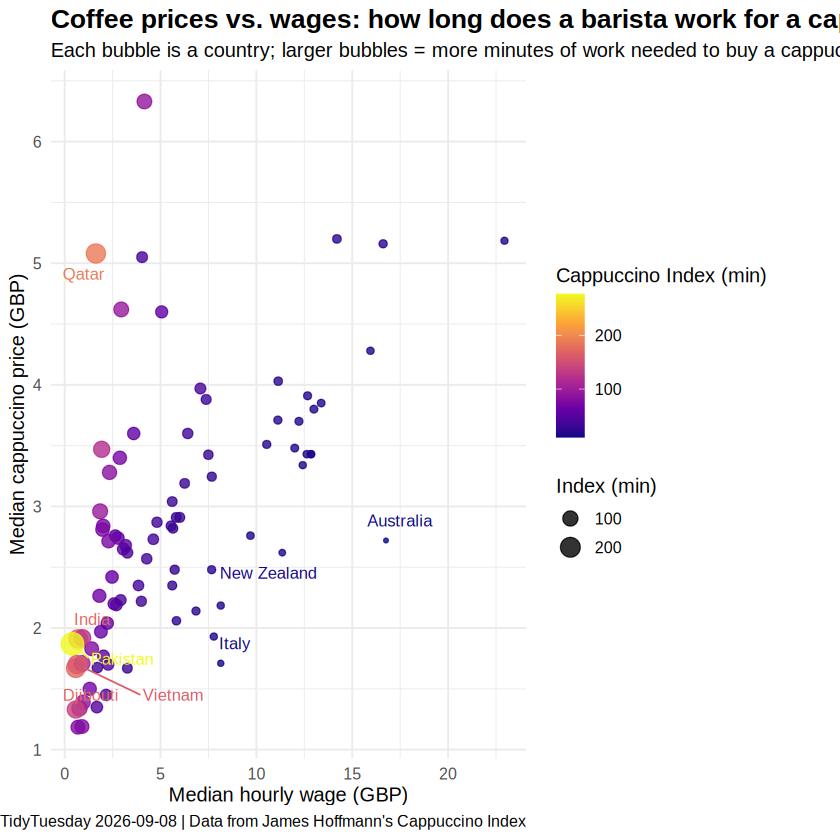

In [1]:
# Install packages if needed
if (!requireNamespace("tidyverse", quietly = TRUE)) install.packages("tidyverse")
if (!requireNamespace("ggrepel", quietly = TRUE)) install.packages("ggrepel")

library(tidyverse)
library(ggrepel)

# Load data
cafe <- readr::read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-09-08/cafe.csv")
cappuccino_index <- readr::read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-09-08/cappuccino_index.csv")

# Fix non-breaking spaces in country names
cafe$country <- gsub("\u00a0", " ", cafe$country)
cappuccino_index$country <- gsub("\u00a0", " ", cappuccino_index$country)

# Country-level summary: median price and wage, plus Cappuccino Index
country_summary <- cafe %>%
    group_by(country) %>%
    summarise(
        median_wage_gbp = median(hourly_wage_gbp, na.rm = TRUE),
        median_price_gbp = median(price_gbp, na.rm = TRUE),
        n_cafes = n(),
        .groups = "drop"
    ) %>%
    left_join(
        cappuccino_index %>%
            select(country, index, minutes, seconds),
        by = "country"
    ) %>%
    filter(!is.na(index))

# Label a subset of countries for readability
label_countries <- country_summary %>%
    arrange(desc(index)) %>%
    slice_head(n = 5) %>%
    bind_rows(
        country_summary %>%
            arrange(index) %>%
            slice_head(n = 3)
    )

# Plot: median wage vs median cappuccino price, bubble size = minutes to earn the drink
ggplot(country_summary, aes(
    x = median_wage_gbp,
    y = median_price_gbp,
    size = index,
    color = index
)) +
    geom_point(alpha = 0.8) +
    geom_text_repel(
        data = label_countries,
        aes(label = country),
        size = 3.5,
        max.overlaps = Inf,
        box.padding = 0.5,
        point.padding = 0.25
    ) +
    scale_color_viridis_c(option = "plasma", name = "Cappuccino Index (min)") +
    scale_size_continuous(name = "Index (min)") +
    labs(
        title = "Coffee prices vs. wages: how long does a barista work for a cappuccino?",
        subtitle = "Each bubble is a country; larger bubbles = more minutes of work needed to buy a cappuccino.",
        x = "Median hourly wage (GBP)",
        y = "Median cappuccino price (GBP)",
        caption = "Source: TidyTuesday 2026-09-08 | Data from James Hoffmann's Cappuccino Index"
    ) +
    theme_minimal(base_size = 12) +
    theme(
        plot.title = element_text(face = "bold", size = 16),
        legend.position = "right"
    )